In [34]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import SGDClassifier, Perceptron, LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from lib.help import load_json_data
from lib.paths import W_TOR_TRAIN_ALL
torvik_women = [
    "Rk",
    "Team",
    "Seed",
    "Finish",
    "Tourney",
    "Year",
    "Conf",
    "G",
    "Rec",
    "AdjOE",
    "AdjDE",
    "Barthag",
    "EFG%",
    "EFGD%",
    "TOR",
    "TORD",
    "ORB",
    "DRB",
    "FTR",
    "FTRD",
    "2P%",
    "2P%D",
    "3P%",
    "3P%D",
    "3PR",
    "3PRD",
    "Adj T.",
    "WAB",
]

data = load_json_data(W_TOR_TRAIN_ALL)
df = pd.DataFrame(data, columns=torvik_women)

In [35]:
X = df.drop(columns=['Rk', 'Tourney', 'Team', 'Conf', 'Year', 'Seed', 'Finish', 'Rec', 'G', 'WAB'])
y = df['Tourney']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                    test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=10000, solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.91


In [36]:
# Coefficients and Odds Ratios
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)


# Display feature importance using coefficients and odds ratios
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
})
print("\nFeature Importance (Coefficient and Odds Ratio):")
print(feature_importance.sort_values(by='Coefficient', ascending=False))


Feature Importance (Coefficient and Odds Ratio):
    Feature  Coefficient  Odds Ratio
6      TORD     0.308606    1.361526
0     AdjOE     0.267746    1.307015
11      2P%     0.108653    1.114775
9       FTR     0.033501    1.034068
14     3P%D     0.027114    1.027485
13      3P%     0.019356    1.019544
15      3PR     0.007154    1.007179
7       ORB    -0.007302    0.992725
12     2P%D    -0.045586    0.955438
10     FTRD    -0.052992    0.948388
5       TOR    -0.066186    0.935957
1     AdjDE    -0.069754    0.932623
16     3PRD    -0.072701    0.929879
8       DRB    -0.087169    0.916522
3      EFG%    -0.094578    0.909757
17   Adj T.    -0.099708    0.905102
4     EFGD%    -0.298273    0.742099
2   Barthag    -2.292848    0.100979


In [37]:
# Permutation Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
})
print("\nPermutation Importance:")
print(perm_importance_df.sort_values(by='Importance Mean', ascending=False))


Permutation Importance:
    Feature  Importance Mean  Importance Std
0     AdjOE         0.130798        0.013790
2   Barthag         0.022449        0.007191
6      TORD         0.022016        0.008566
4     EFGD%         0.011070        0.007097
3      EFG%         0.008411        0.005803
1     AdjDE         0.006617        0.004878
8       DRB         0.004329        0.004451
11      2P%         0.002536        0.005430
9       FTR         0.001113        0.002898
12     2P%D         0.000742        0.003340
14     3P%D         0.000557        0.001925
15      3PR         0.000557        0.001925
16     3PRD         0.000371        0.004295
5       TOR        -0.000371        0.003661
7       ORB        -0.000433        0.001566
13      3P%        -0.000557        0.001526
10     FTRD        -0.000866        0.004588
17   Adj T.        -0.003525        0.003931


In [38]:
# Recursive Feature Elimination (RFE)
# 1. Scale first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Logistic model with higher iterations
rfe_model = LogisticRegression(
    max_iter=5000,
    solver="lbfgs"
)

# 3. RFE
rfe = RFE(rfe_model, n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

# 4. Get feature names
rfe_features = X_train.columns[rfe.support_]

print("\nSelected Features by RFE:")
print(rfe_features)


Selected Features by RFE:
Index(['AdjOE', 'AdjDE', 'Barthag', 'EFGD%', 'TOR', 'TORD', 'DRB', 'FTRD',
       '2P%D', '3P%D'],
      dtype='object')


In [39]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy # Requires: pip install boruta

# 1. SETUP - Aiming for top 10 features across all methods
n_select = 10
votes = pd.DataFrame({'Feature': X.columns})

# 2. FILTER METHODS (Statistical)
# ANOVA F-Value
skb = SelectKBest(f_classif, k=n_select).fit(X, y)
votes['SelectKBest'] = skb.get_support()

# Mutual Information (Captures non-linear dependencies)
mi = SelectKBest(mutual_info_classif, k=n_select).fit(X, y)
votes['Mutual_Info'] = mi.get_support()

# 3. WRAPPER METHODS (Iterative)
# RFE with Logistic Regression
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=n_select).fit(X, y)
votes['RFE'] = rfe.support_

# Boruta (Proves features are better than random shadow noise)
rf_boruta = RandomForestClassifier(n_jobs=-1, max_depth=5)
boruta = BorutaPy(rf_boruta, n_estimators='auto', verbose=0).fit(X.values, y.values)
votes['Boruta'] = boruta.support_

# 4. EMBEDDED METHODS (Model-Specific)
# Lasso (L1 Regularization - forces weak coefficients to zero)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.2).fit(X, y)
lasso_top = np.argsort(abs(lasso.coef_[0]))[-n_select:]
votes['Lasso_L1'] = [i in lasso_top for i in range(len(X.columns))]

# Random Forest Importance (Tree-based impurity reduction)
rf = RandomForestClassifier(n_estimators=100).fit(X, y)
rf_top = np.argsort(rf.feature_importances_)[-n_select:]
votes['RandomForest'] = [i in rf_top for i in range(len(X.columns))]

# 5. FINAL TALLY
votes['Total_Votes'] = votes.iloc[:, 1:].sum(axis=1)
# Filter for features selected by at least 3 methods
consensus_features = votes[votes['Total_Votes'] >= 3].sort_values(by='Total_Votes', ascending=False)

print(consensus_features[['Feature', 'Total_Votes']])

    Feature  Total_Votes
0     AdjOE            6
1     AdjDE            6
12     2P%D            6
5       TOR            6
11      2P%            5
2   Barthag            5
8       DRB            5
4     EFGD%            5
3      EFG%            4
6      TORD            4
13      3P%            4
14     3P%D            3


In [40]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Isolate the Consensus Features
# Assuming 'consensus_features' is the list of names from the previous step
X_final = X[consensus_features['Feature']]

# 2. Re-split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Fit the Final Model
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train_scaled, y_train)

# 4. Generate Predictions
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1] # Probability of being a '1' (In Tourney)

# 5. Print Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.93      0.97      0.95       373
        True       0.79      0.63      0.70        76

    accuracy                           0.91       449
   macro avg       0.86      0.80      0.82       449
weighted avg       0.90      0.91      0.90       449

ROC-AUC Score: 0.9333


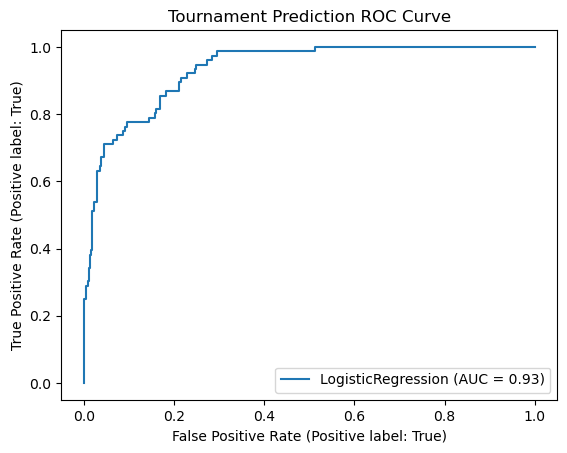

In [41]:
RocCurveDisplay.from_estimator(final_model, X_test_scaled, y_test)
plt.title("Tournament Prediction ROC Curve")
plt.show()

In [42]:
import time
def get_classifier_best(Classifier, X, y, tune=None, **params):
    print('Training classifier \'{}\'...'.format(Classifier.__name__))
    start_time = time.time()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=13, shuffle=True)
    clf = Classifier(**params)
    best_score = 0

    if tune:
        search = GridSearchCV(clf, tune, refit=True, n_jobs=-1)
        search.fit(X_train, y_train)

        best_params = search.best_params_
        best_score = search.best_score_
        print('{} scores: {}\twith {}'.format(Classifier.__name__, best_score, best_params))
        clf = search.best_estimator_
    else:
        cv_results = cross_validate(clf, X, y, cv=5)
        scores = cv_results['test_score']
        best_score = np.mean(scores)
        print('{} scores: {} ± {}'.format(Classifier.__name__, best_score, np.std(scores)))

        clf.fit(X_train, y_train)
    if hasattr(clf, 'feature_importances_') and hasattr(clf, 'feature_names_in_'):
        importances = sorted(zip(clf.feature_names_in_, clf.feature_importances_), key=lambda x: x[1], reverse=True)
        print('Feature Importances: {}'.format(importances))
    duration = time.time() - start_time
    print(f"⏱️ {Classifier.__name__} took {duration:.2f} seconds")
    return clf, best_score

In [43]:

# run ML models
models = []

tune_params = [{'strategy': ['uniform'], 'random_state': [13]}]
result = get_classifier_best(DummyClassifier, X, y, tune=None, strategy='uniform')
models.append(result)

print()
tune_params = {
    'C': np.logspace(-3, 2, 10),   # much better coverage
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced'],
    'max_iter': [10000]
}

result = get_classifier_best(LogisticRegression, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': [None, 'sqrt']
}
result = get_classifier_best(GradientBoostingClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    'learning_rate': [0.01, 0.03, 0.05],
    'max_iter': [100, 200, 400],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [20, 40, 80],
    'l2_regularization': [0.0, 0.1, 1.0]
}
result = get_classifier_best(HistGradientBoostingClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    'C': np.logspace(-3, 2, 8),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}
result = get_classifier_best(SVC, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    'loss': ['log_loss', 'modified_huber'],
    'alpha': np.logspace(-5, -2, 5),
    'penalty': ['l2', 'l1'],
    'max_iter': [5000],
    'class_weight': [None, 'balanced']
}
result = get_classifier_best(SGDClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {}
result = get_classifier_best(GaussianNB, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {}
result = get_classifier_best(Perceptron, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
}
result = get_classifier_best(AdaBoostClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    'n_neighbors': [5, 11, 21, 31],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],
    'metric': ['minkowski']
}
result = get_classifier_best(KNeighborsClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'ccp_alpha': [0.0, 0.001, 0.01]
}
result = get_classifier_best(DecisionTreeClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {
    'n_estimators': [200, 400, 800],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True],
    'class_weight': [None, 'balanced']
}
result = get_classifier_best(RandomForestClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'max_iter_predict': [10, 100, 200]}
result = get_classifier_best(GaussianProcessClassifier, X, y, tune=tune_params)
models.append(result)

best_model, best_score = max(models, key=lambda x: x[1])
print('\nSelecting \'{}\' as best model with score: {}'.format(best_model.__class__.__name__, best_score))

Training classifier 'DummyClassifier'...
DummyClassifier scores: 0.484945768039713 ± 0.028388121285741332
⏱️ DummyClassifier took 0.01 seconds

Training classifier 'LogisticRegression'...
LogisticRegression scores: 0.9249070631970261	with {'C': 0.001, 'class_weight': None, 'max_iter': 10000, 'penalty': 'l2', 'solver': 'liblinear'}
⏱️ LogisticRegression took 1.26 seconds

Training classifier 'GradientBoostingClassifier'...
GradientBoostingClassifier scores: 0.9286245353159851	with {'learning_rate': 0.05, 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.8}
Feature Importances: [('Barthag', 0.3277723458864444), ('AdjDE', 0.18634441796726803), ('AdjOE', 0.11350914967480674), ('2P%', 0.08455605894321737), ('TOR', 0.052808555419239324), ('EFGD%', 0.04412722356639229), ('3P%', 0.043813965848188356), ('EFG%', 0.030980197229992946), ('2P%D', 0.025660700304700752), ('Adj T.', 0.022656909501646998), ('TORD', 0.01287897893

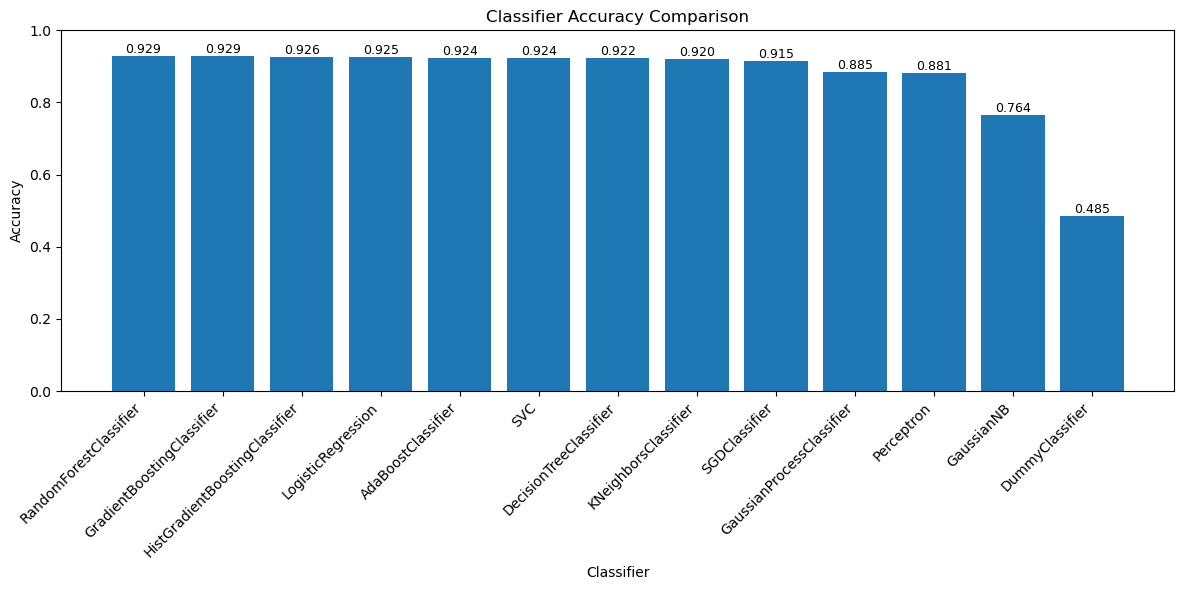

In [44]:
import matplotlib.pyplot as plt

models_sorted = sorted(models, key=lambda x: x[1], reverse=True)

model_names = [m.__class__.__name__ for m, s in models_sorted]
scores = [s for m, s in models_sorted]

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, scores)

# Optional: show values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylabel("Accuracy")
plt.xlabel("Classifier")
plt.title("Classifier Accuracy Comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)  # assuming accuracy
plt.tight_layout()
plt.show()


SVC, GradientBoostingClassifier, Logistic Regression
https://chatgpt.com/share/697c3918-7494-8005-a060-587f1a0b7775